# **Clinical Trial Data Analysis & Insights (Healthcare Analytics Project)**

This project focuses on analyzing real-world clinical trial data to uncover trends in research activity, disease focus, and study patterns. The goal is to generate actionable insights that can support data-driven decision-making in the healthcare and pharmaceutical industry.

## Objective

To analyze clinical trial data and extract meaningful insights related to:
- Trial status distribution
- Disease/condition trends
- Organizations conducting trials
- Study types and phases
- Time-based trends in clinical research

This project demonstrates how data analytics can be applied to healthcare datasets to support research planning and decision-making.

## Tools & Technologies

- Python (Pandas, Matplotlib, Seaborn)
- SQL (SQLite for analytical queries)
- Jupyter Notebook

Dataset: ClinicalTrials.gov dataset (public healthcare dataset)

## Data Loading

In this step, we load the clinical trials dataset and preview its structure.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('C:/clinical-trial-analysis/data/clin_trials.csv')
df.head()

,Unnamed: 0,Organization Full Name,Organization Class,Responsible Party,Brief Title,Full Title,Overall Status,Start Date,Standard Age,Conditions,Primary Purpose,Interventions,Intervention Description,Study Type,Phases,Outcome Measure,Medical Subject Headings
0,0,Montefiore Medical Center,OTHER,SPONSOR,Kinesiotape for Edema After Bilateral Total Kn...,"Effect of Kinesiotaping on Edema Management, P...",COMPLETED,2021-10-18,ADULT OLDER_ADULT,"Arthroplasty Complications, Arthroplasty, Repl...",TREATMENT,Kinesio(R)Tape for edema control,"Kinesio(R)Tape is an elastic, cotton tape with...",INTERVENTIONAL,NaN,Change from baseline and during 1-2-day time i...,Edema
1,1,Seoul National University Hospital,OTHER,Unknown,An Open-labeled Trial of Ramipril in Patients ...,An Open-labeled Trial of Ramipril in Patients ...,COMPLETED,2004-10,ADULT OLDER_ADULT,Migraine With Hypertension,TREATMENT,Ramipril,ramipril 2.5mg twice a day,INTERVENTIONAL,PHASE2,headache frequency,Migraine Disorders Hypertension
2,2,Federico II University,OTHER,PRINCIPAL_INVESTIGATOR,OCTA in Epivascular Glia After Dex Implant,Evaluation of Changes in Epivascular Glia Befo...,COMPLETED,2021-01-01,ADULT OLDER_ADULT,Diabetic Retinopathy,Unknown,Dexamethasone intravitreal implant,Dexamethasone intravitreal implant,OBSERVATIONAL,Unknown,Changes in epivascular glia after Dexamethason...,Diabetic Retinopathy
3,3,Sidney Kimmel Comprehensive Cancer Center at J...,OTHER,SPONSOR,Preoperative Immune Checkpoint Inhibitor for P...,Preoperative Immune Checkpoint Inhibitor Thera...,COMPLETED,2019-07-08,ADULT OLDER_ADULT,"Head and Neck Squamous Cell Carcinoma, Head an...",TREATMENT,Nivolumab 480mg and surgical resection,One dose of Nivolumab 480mg given four weeks p...,INTERVENTIONAL,PHASE2,Safety as measured by number of participants w...,"Carcinoma Carcinoma, Squamous Cell Head and Ne..."
4,4,Northwestern University,OTHER,SPONSOR,Genistein in Treating Patients With Prostate C...,Phase 2 Trial of Genistein in Men With Circula...,TERMINATED,2011-02-03,ADULT OLDER_ADULT,"Adenocarcinoma of the Prostate, Recurrent Pros...",TREATMENT,"genistein, placebo, therapeutic conventional s...","Given orally, Given orally, Radical prostatect...",INTERVENTIONAL,PHASE2,Number of Circulating Prostate Cells (CPCs) in...,Prostatic Neoplasms


In [7]:
df.columns

Index(['Unnamed: 0', 'Organization Full Name', 'Organization Class',
       'Responsible Party', 'Brief Title', 'Full Title', 'Overall Status',
       'Start Date', 'Standard Age', 'Conditions', 'Primary Purpose',
       'Interventions', 'Intervention Description', 'Study Type', 'Phases',
       'Outcome Measure', 'Medical Subject Headings'],
      dtype='object')

## Data Cleaning

We clean column names, handle missing values, and prepare the dataset for analysis.

In [9]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
df = df.drop(columns=['Unnamed:_0'], errors='ignore')
df.columns

Index(['Organization_Full_Name', 'Organization_Class', 'Responsible_Party',
       'Brief_Title', 'Full_Title', 'Overall_Status', 'Start_Date',
       'Standard_Age', 'Conditions', 'Primary_Purpose', 'Interventions',
       'Intervention_Description', 'Study_Type', 'Phases', 'Outcome_Measure',
       'Medical_Subject_Headings'],
      dtype='object')

In [10]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df[df['Overall_Status'].notna()]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495712 entries, 0 to 496614
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Organization_Full_Name    495712 non-null  object
 1   Organization_Class        495712 non-null  object
 2   Responsible_Party         495712 non-null  object
 3   Brief_Title               495712 non-null  object
 4   Full_Title                495712 non-null  object
 5   Overall_Status            495712 non-null  object
 6   Start_Date                495712 non-null  object
 7   Standard_Age              495711 non-null  object
 8   Conditions                495712 non-null  object
 9   Primary_Purpose           495712 non-null  object
 10  Interventions             495712 non-null  object
 11  Intervention_Description  495712 non-null  object
 12  Study_Type                495712 non-null  object
 13  Phases                    311872 non-null  object
 14  Outcome_M

## Date Processing

We convert the start date into datetime format and extract the year for time-based analysis.

In [12]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')
df['Year'] = df['Start_Date'].dt.year
df = df[df['Year'].notna()]
df[['Start_Date', 'Year']].head()

,Start_Date,Year
0,2021-10-18,2021.0
2,2021-01-01,2021.0
3,2019-07-08,2019.0
4,2011-02-03,2011.0
6,2019-01-01,2019.0


## Feature Engineering

We create a new column `Main_Condition` to simplify multiple conditions into a primary category for better analysis.

In [14]:
# Create Main_Condition BEFORE SQL
df['Main_Condition'] = df['Conditions'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

# Clean values
df['Main_Condition'] = df['Main_Condition'].replace({
    'Healthy Volunteers': 'Healthy'
})

# Standardize COVID
df['Main_Condition'] = df['Main_Condition'].str.replace('covid19', 'COVID-19', case=False)

## SQL Analysis (Simulating Real-World Queries)

In this section, we use SQL queries to extract insights from the dataset, similar to how data analysts work with databases.

In [16]:
import sqlite3

# Create in-memory database
conn = sqlite3.connect(':memory:')

# Load dataframe into SQL
df.to_sql('clinical_trials', conn, index=False, if_exists='replace')

276490

### Top Trial Status Distribution

In [18]:
query = """
SELECT Overall_Status, COUNT(*) as count
FROM clinical_trials
GROUP BY Overall_Status
ORDER BY count DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Overall_Status,count
0,COMPLETED,124316
1,RECRUITING,64499
2,UNKNOWN,33682
3,ACTIVE_NOT_RECRUITING,18047
4,NOT_YET_RECRUITING,13728
5,TERMINATED,12462
6,WITHDRAWN,5045
7,ENROLLING_BY_INVITATION,3687
8,SUSPENDED,1024


### Top Organizations Conducting Trials

In [20]:
query = """
SELECT Organization_Full_Name, COUNT(*) as trials
FROM clinical_trials
GROUP BY Organization_Full_Name
ORDER BY trials DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Organization_Full_Name,trials
0,National Institutes of Health Clinical Center ...,3656
1,Assiut University,2728
2,Cairo University,2576
3,GlaxoSmithKline,2224
4,M.D. Anderson Cancer Center,1816
5,Assistance Publique - Hôpitaux de Paris,1696
6,Mayo Clinic,1580
7,Novartis,1336
8,Pfizer,1290
9,VA Office of Research and Development,1269


### Study Type Distribution

In [22]:
query = """
SELECT Study_Type, COUNT(*) as count
FROM clinical_trials
GROUP BY Study_Type;
"""

pd.read_sql(query, conn)

,Study_Type,count
0,INTERVENTIONAL,207000
1,OBSERVATIONAL,69490


### Clinical Trials Trend Over Years

In [24]:
query = """
SELECT Year, COUNT(*) as trials
FROM clinical_trials
WHERE Year BETWEEN 2000 AND 2023
GROUP BY Year
ORDER BY Year;
"""

pd.read_sql(query, conn)

,Year,trials
0,2000.0,251
1,2001.0,282
2,2002.0,331
3,2003.0,471
4,2004.0,580
5,2005.0,686
6,2006.0,933
7,2007.0,1056
8,2008.0,1249
9,2009.0,1549


### Top Conditions in Clinical Trials

In [26]:
query = """
SELECT Main_Condition, COUNT(*) as count
FROM clinical_trials
GROUP BY Main_Condition
ORDER BY count DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Main_Condition,count
0,Healthy,4982
1,COVID-19,3765
2,Breast Cancer,3168
3,Stroke,2447
4,Diabetes Mellitus,2199
5,Obesity,2195
6,Pain,1946
7,Prostate Cancer,1583
8,Cancer,1464
9,Parkinson Disease,1387


### Insight: SQL Analysis

- SQL confirms trends observed in Python analysis
- Most trials are completed or recruiting
- Interventional studies dominate
- SQL enables efficient analysis of large datasets

## Exploratory Data Analysis (EDA)

We analyze key aspects of the dataset including trial status, conditions, organizations, and study types.

In [29]:
df['Overall_Status'].value_counts().head(10)

Overall_Status
COMPLETED                  124316
RECRUITING                  64499
UNKNOWN                     33682
ACTIVE_NOT_RECRUITING       18047
NOT_YET_RECRUITING          13728
TERMINATED                  12462
WITHDRAWN                    5045
ENROLLING_BY_INVITATION      3687
SUSPENDED                    1024
Name: count, dtype: int64

### Insight: Trial Status

- Majority of trials are completed, indicating strong research output
- A large number of trials are still recruiting, showing ongoing activity
- Presence of terminated and withdrawn trials reflects real-world research challenges
- A significant presence of 'Unknown' values highlights real-world data quality challenges in healthcare datasets.

In [31]:
df['Organization_Full_Name'].value_counts().head(10)

Organization_Full_Name
National Institutes of Health Clinical Center (CC)    3656
Assiut University                                     2728
Cairo University                                      2576
GlaxoSmithKline                                       2224
M.D. Anderson Cancer Center                           1816
Assistance Publique - Hôpitaux de Paris               1696
Mayo Clinic                                           1580
Novartis                                              1336
Pfizer                                                1290
VA Office of Research and Development                 1269
Name: count, dtype: int64

### Insight: Organizations

- Major contributors include government institutions like NIH and NCI
- Pharmaceutical companies such as Pfizer, Novartis, and AstraZeneca are key players
- Indicates collaboration between public research and private pharma industry

In [33]:
df['Study_Type'].value_counts()

Study_Type
INTERVENTIONAL    207000
OBSERVATIONAL      69490
Name: count, dtype: int64

### Insight: Study Type

- Interventional studies dominate, indicating focus on treatment development
- Observational studies are fewer but still significant

In [35]:
df['Year'].value_counts().sort_index()

Year
1916.0     1
1917.0     1
1963.0     1
1965.0     1
1968.0     1
          ..
2026.0    30
2027.0     5
2028.0     3
2030.0     3
2097.0     3
Name: count, Length: 62, dtype: int64

### Insight: Time Trends

- Clinical trials have increased significantly after 2000
- Indicates growth in healthcare research and innovation
- Future-dated trials represent planned or ongoing studies

## Advanced Analysis

We refine the dataset by simplifying conditions and analyzing deeper patterns such as phases and interventions.

In [38]:
# Split multiple conditions
df['Main_Condition'] = df['Conditions'].apply(lambda x: x.split(',')[0])
df['Main_Condition'] = df['Main_Condition'].replace({
    'Healthy Volunteers': 'Healthy',
    'Covid19': 'COVID-19'
})
df['Main_Condition'].value_counts().head(10)

Main_Condition
Healthy              4982
COVID-19             3687
Breast Cancer        3168
Stroke               2447
Diabetes Mellitus    2199
Obesity              2195
Pain                 1946
Prostate Cancer      1583
Cancer               1464
Parkinson Disease    1387
Name: count, dtype: int64

### Insight: Conditions

- Cancer and chronic diseases dominate clinical research
- Lifestyle diseases like obesity and hypertension are highly studied
- Healthy participants are used as control groups

In [40]:
df['Phases'].value_counts()

Phases
Unknown           69548
PHASE2            26801
PHASE1            21298
PHASE3            16083
PHASE4            12281
PHASE1, PHASE2     7579
EARLY_PHASE1       3285
PHASE2, PHASE3     2879
Name: count, dtype: int64

### Insight: Trial Phases

- Phase 2 and Phase 1 trials are most common
- Large number of unknown values indicates incomplete data

In [42]:
df['Interventions'] = df['Interventions'].str.strip().str.lower()

df['Interventions'] = df['Interventions'].replace({
    'no intervention': 'No Intervention'
})
df['Interventions'].value_counts().head(10)

Interventions
unknown            23372
No Intervention     1472
questionnaire        419
exercise             390
survey               242
blood sample         220
mri                  203
observational        187
data collection      183
ultrasound           178
Name: count, dtype: int64

### Insight: Interventions

- Common interventions include exercise, surveys, and diagnostic tests
- Presence of 'no intervention' indicates observational studies

## Data Visualization

We visualize key insights using bar charts and line plots for better understanding.

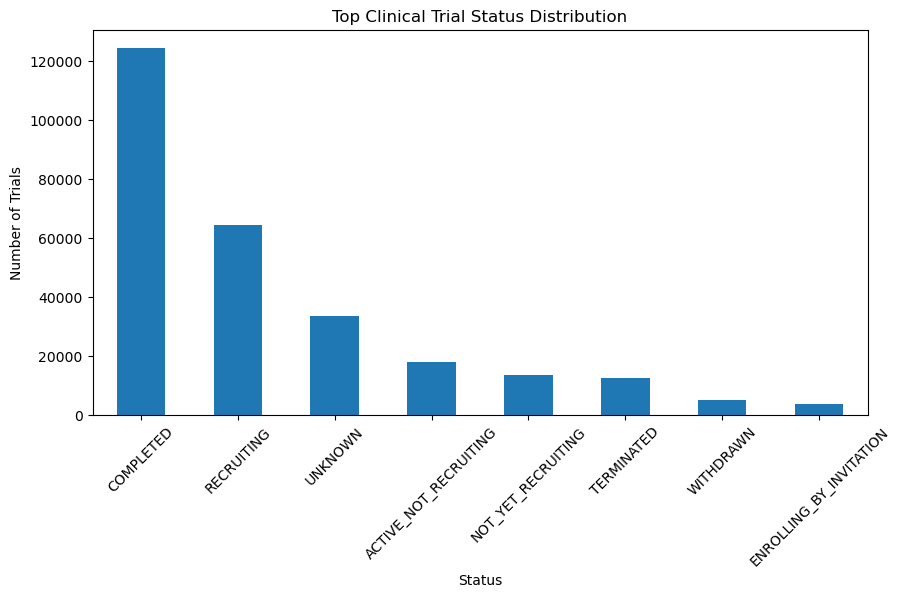

In [45]:
top_status = df['Overall_Status'].value_counts().head(8)

plt.figure(figsize=(10,5))
top_status.plot(kind='bar')
plt.title("Top Clinical Trial Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45)
plt.show()

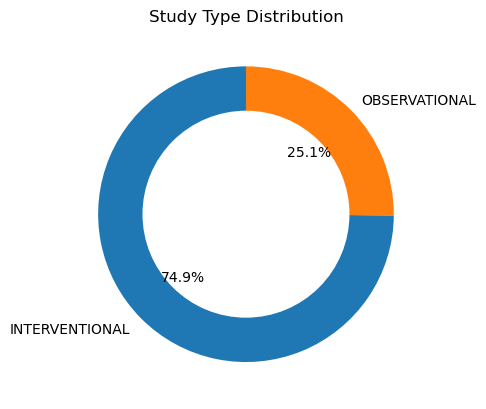

In [46]:
plt.pie(
    df['Study_Type'].value_counts(),
    labels=df['Study_Type'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Study Type Distribution")
plt.show()

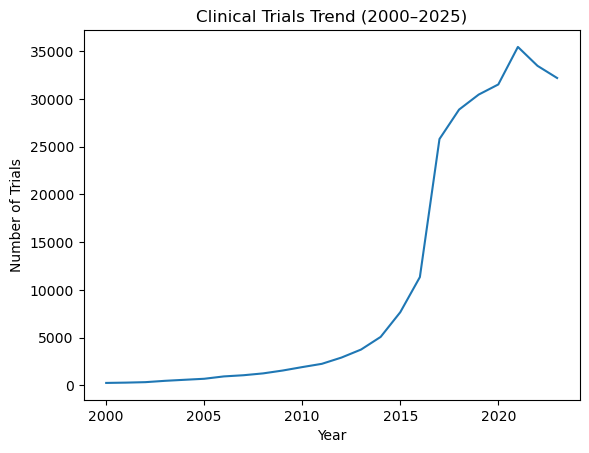

In [47]:
df_filtered = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)]

df_filtered['Year'].value_counts().sort_index().plot(kind='line')
plt.title("Clinical Trials Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.show()

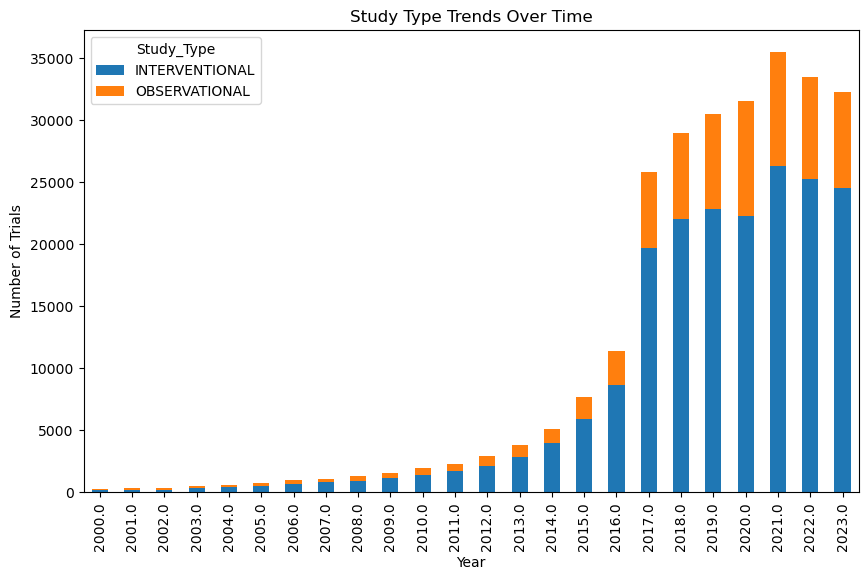

In [48]:
pivot = pd.crosstab(df_filtered['Year'], df_filtered['Study_Type'])

pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Study Type Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.show()

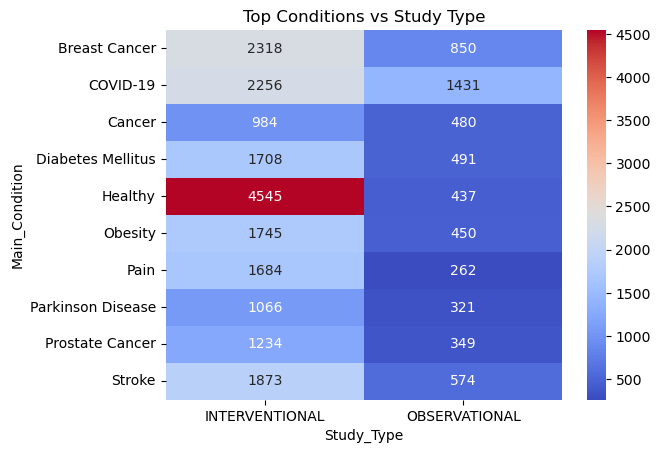

In [49]:
top_conditions = df['Main_Condition'].value_counts().head(10).index

pivot = pd.crosstab(
    df[df['Main_Condition'].isin(top_conditions)]['Main_Condition'],
    df['Study_Type']
)

sns.heatmap(pivot, annot=True, fmt='d', cmap='coolwarm')
plt.title("Top Conditions vs Study Type")
plt.show()

### Visualization Summary

- Status distribution highlights dominance of completed trials
- Condition plots show major disease focus areas
- Study type visualization confirms treatment-focused research
- Time trend shows rapid growth in recent years
- Advanced visualizations such as stacked bar charts and heatmaps provide deeper insights into relationships between study types and medical conditions.

## Final Conclusion

- Clinical trials have increased significantly over time, especially after 2000
- Majority of trials are interventional, focusing on treatment development
- Cancer and chronic diseases are the most researched areas
- Both government organizations and pharmaceutical companies play key roles
- Data contains missing and unknown values, reflecting real-world data limitations

This project demonstrates how data analytics can be applied to healthcare datasets to extract meaningful insights and support research decision-making.
